# 0407 — HDBSCAN Clustering: The 44 Dropoff Hubs

Builds the project's canonical geographic zoning: 72 hand-drawn polygons for named neighborhoods, cross-validated against 44 HDBSCAN clusters auto-discovered from real dropoff density. Iterates through several naming/ID fix passes (documented as they happened, including a caught-and-corrected zone-naming swap), distills the result into an H3 hexagon grid, and forges the final "Golden Master" table joining spatial and operational data.

<div align="center">
<picture>
  <source media="(prefers-color-scheme: dark)" srcset="../assets/0407_diagram1-dark.png">
  <source media="(prefers-color-scheme: light)" srcset="../assets/0407_diagram1-light.png">
  <img alt="0407_diagram1 flowchart" src="../assets/0407_diagram1-light.png" width="760">
</picture>
</div>


## Phase 1 — Polygon geometry

Loads the 72 hand-drawn polygons, assigns each a numeric ID, and computes their centroids for labeling. Goes through two ID-assignment passes: a simple sequential one, then a duplicate-proof version that fixes a Tecamachalco naming collision (two polygons sharing one name needed two distinct IDs).

#### 1.1 — Command center & GeoJSON setup

Connects to `pienza.db` and loads the base polygon file into `gdf`.

In [21]:
import copy
import os
import warnings

import folium
import geopandas as gpd
import h3
import hdbscan
import numpy as np
import pandas as pd
import plotly.express as px
from folium import plugins
from IPython.display import Markdown, display
from shapely.geometry import Polygon
from sklearn.preprocessing import StandardScaler
from sqlalchemy import create_engine

warnings.filterwarnings('ignore')

display(Markdown("### Initialization, connection, and polygon loading (Codespaces)"))

# --- 1. Local paths ---
PREFIX = "0407"
ASSETS_DIR = "/workspaces/pienza/assets"
DUMP_DIR = "/workspaces/pienza/data/dumped_files"
DB_PATH = "/workspaces/pienza/data/pienza.db"

INPUT_GEOJSON = f"{ASSETS_DIR}/poly.geojson"
OUTPUT_GEOJSON = f"{DUMP_DIR}/{PREFIX}_poly_numbered_streamlit.geojson"
OUTPUT_CSV = f"{DUMP_DIR}/{PREFIX}_polygon_latex_index_streamlit.csv"

# --- 2. SQLite engine ---
if not os.path.exists(DB_PATH):
    print(f"CRITICAL: pienza.db not found at {DB_PATH}")
else:
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    print("SQL engine connected to local Pienza DB.")

# --- 3. Load geometry (birth of 'gdf') ---
try:
    if not os.path.exists(INPUT_GEOJSON):
        raise FileNotFoundError(f"Base file not found: {INPUT_GEOJSON}")

    gdf = gpd.read_file(INPUT_GEOJSON)

    # Standardize the name column
    if 'Name' in gdf.columns:
        gdf = gdf.rename(columns={'Name': 'zone_name'})
    elif 'name' in gdf.columns:
        gdf = gdf.rename(columns={'name': 'zone_name'})

    print(f"Polygons loaded successfully into 'gdf'. Total: {len(gdf)} zones.")
    print(f"Assets configured at: {ASSETS_DIR}")
    print(f"Dumps configured at: {DUMP_DIR}")

except Exception as e:
    print(f"ERROR LOADING GEOJSON: {e}")


### Initialization, connection, and polygon loading (Codespaces)

SQL engine connected to local Pienza DB.
Polygons loaded successfully into 'gdf'. Total: 72 zones.
Assets configured at: /workspaces/pienza/assets
Dumps configured at: /workspaces/pienza/data/dumped_files


#### 1.2 — Inject IDs & generate artifacts (first pass)

Sorts zones alphabetically, assigns a sequential numeric ID, and exports the numbered GeoJSON plus a LaTeX-ready index CSV. Superseded by the duplicate-proof version in 1.4 (Tecamachalco needed two IDs, not one).

In [22]:
# 1. Sort alphabetically so the final LaTeX table is easy for the reader to scan
gdf = gdf.sort_values('zone_name').reset_index(drop=True)

# 2. Inject the numerical ID (starting at 1)
gdf['map_id'] = gdf.index + 1

# 3. Export the numbered GeoJSON for Kepler.gl
gdf.to_file(OUTPUT_GEOJSON, driver='GeoJSON')
display(Markdown(f"Numbered GeoJSON saved: `{OUTPUT_GEOJSON}`"))
display(Markdown("Drag and drop this file directly into the Kepler.gl web UI."))

# 4. Extract and export the clean index for the LaTeX table
df_index = gdf[['map_id', 'zone_name']]
df_index.to_csv(OUTPUT_CSV, index=False)
display(Markdown(f"LaTeX reference CSV saved: `{OUTPUT_CSV}`"))

# Preview the mapping
display(df_index.head(10))


Numbered GeoJSON saved: `/workspaces/pienza/data/dumped_files/0407_poly_numbered_streamlit.geojson`

Drag and drop this file directly into the Kepler.gl web UI.

LaTeX reference CSV saved: `/workspaces/pienza/data/dumped_files/0407_polygon_latex_index_streamlit.csv`

,map_id,zone_name
0,1,agwa_bezares
1,2,ahuehuetes_norte
2,3,ahuehuetes_sur
3,4,anahuac_1
4,5,anzures
5,6,ave_club_de_golf_lomas
6,7,bahias
7,8,blvrd_anahuac
8,9,bondojito_asf
9,10,bosque_1


#### 1.3 — Centroid calculation (first pass)

Projects to a flat CRS (Web Mercator) to compute geometrically accurate centroids, then reprojects back to lat/lon for web maps.

In [23]:
display(Markdown("### Calculating perfect centroids (EPSG:3857 -> EPSG:4326)"))

try:
    if 'gdf' not in locals():
        raise NameError("GeoDataFrame 'gdf' not in memory. Run 1.1 first.")
    if 'map_id' not in gdf.columns:
        raise KeyError("Missing 'map_id' column. Did you skip the ID injection step?")

    print("Projecting geometry to a flat plane (Web Mercator)...")
    gdf_flat = gdf.to_crs(epsg=3857)

    centroids_flat = gdf_flat.geometry.centroid

    print("Returning centroids to spherical coordinates (lat/lon)...")
    centroids_latlon = centroids_flat.to_crs(epsg=4326)

    df_labels = pd.DataFrame({
        'map_id': gdf['map_id'],
        'zone_name': gdf['zone_name'],
        'lat': centroids_latlon.y,
        'lon': centroids_latlon.x
    })

    OUTPUT_LABELS = f"{DUMP_DIR}/{PREFIX}_polygon_labels_streamlit.csv"
    df_labels.to_csv(OUTPUT_LABELS, index=False)

    print(f"Math complete. {len(df_labels)} centroids calculated.")
    display(Markdown(f"Label file ready for Streamlit/Kepler: `{OUTPUT_LABELS}`"))

    display(df_labels.head())

except Exception as e:
    print(f"ERROR IN CENTROID CALCULATION: {e}")


### Calculating perfect centroids (EPSG:3857 -> EPSG:4326)

Projecting geometry to a flat plane (Web Mercator)...
Returning centroids to spherical coordinates (lat/lon)...
Math complete. 72 centroids calculated.


Label file ready for Streamlit/Kepler: `/workspaces/pienza/data/dumped_files/0407_polygon_labels_streamlit.csv`

,map_id,zone_name,lat,lon
0,1,agwa_bezares,19.386632,-99.249004
1,2,ahuehuetes_norte,19.405377,-99.245778
2,3,ahuehuetes_sur,19.400522,-99.244107
3,4,anahuac_1,19.440151,-99.180125
4,5,anzures,19.431484,-99.178273


#### 1.4 — Duplicate-proof ID injection & centroids (Tecamachalco fix)

Replaces the sequential ID assignment with an explicit `zone_name -> [ids]` map so a zone that legitimately corresponds to two polygons (Tecamachalco) gets two distinct IDs instead of colliding on one.

In [24]:
display(Markdown("### ID injection and label regeneration (Tecamachalco fix)"))

try:
    # --- 1. Path config ---
    INPUT_GEOJSON = f"{ASSETS_DIR}/poly.geojson"
    OUTPUT_GEOJSON = f"{DUMP_DIR}/{PREFIX}_poly_numbered_streamlit.geojson"
    OUTPUT_LABELS = f"{DUMP_DIR}/{PREFIX}_polygon_labels_streamlit.csv"

    if not os.path.exists(INPUT_GEOJSON):
        raise FileNotFoundError(f"Base GeoJSON not found at {INPUT_GEOJSON}")

    gdf = gpd.read_file(INPUT_GEOJSON)

    name_col = 'name' if 'name' in gdf.columns else 'Name'
    gdf = gdf.rename(columns={name_col: 'zone_name'})

    # --- 2. Duplicate-proof map: each value is a LIST. Tecamachalco gets BOTH IDs. ---
    zone_to_ids = {
        'anzures': [1], 'anahuac_1': [2], 'bahias': [3], 'rios': [4], 'juarez_rosa': [5],
        'juarez_soho_house': [6], 'roma_condesa_2': [7], 'roma_condesa_1': [8], 'bosque_1': [9],
        'campo_marte': [10], 'polanco_parque_lincoln': [11], 'polanco_gandhi': [12], 'polanco_5': [13],
        'polanco_parroquia': [14], 'lagos': [15], 'frontera_polanco': [16], 'carso_antara_miyana': [17],
        'polanco_palacio': [18], 'polanco_grupo_mexico': [19], 'polanco_uber_hq': [20], 'irrigacion': [21],
        'sotelo': [22], 'sedena': [23],
        'tecamachalco': [24, 38],  # The fix: assigns 24 first, then 38 to the duplicate
        'fuentes_casino': [25], 'lomas_barrilaco': [26], 'lomas_olimpo': [27], 'lomas_prado_norte': [28],
        'palmas_jp_morgan': [29], 'lomas_fc_cuernavaca': [30], 'lomas_virreyes': [31], 'bosque_2': [32],
        'bondojito_asf': [33], 'bosque_3': [34], 'lomas_trastevere': [35], 'nodo_reforma_palmas': [36],
        'nodo_monte_libano': [37], 'de_las_fuentes': [39], 'herradura_conscripto': [40],
        'de_los_bosques': [41], 'ahuehuetes_norte': [42], 'ahuehuetes_sur': [43], 'reforma_regina': [44],
        'lomas_altas': [45], 'reforma_bnp': [46], 'agwa_bezares': [47], 'sante_fe_patio': [48],
        'santa_fe_quintana': [49], 'santa_fe_tec': [50], 'santa_fe_cumbres_de': [51], 'santa_fe_bosques_de': [52],
        'santa_fe_colegios': [53], 'santa_fe_ibero': [54], 'santa_fe_centro_comercial': [55], 'cruce_echanove': [56],
        'carretera_libre': [57], 'vistahermosa': [58], 'tamarindos': [59], 'bosques_pabellon': [60],
        'loma_de_la_palma': [61], 'carretera_al_olivo': [62], 'vialidad_de_la_barranca': [63], 'el_olivo': [64],
        'blvrd_anahuac': [65], 'universidad_anahuac': [66], 'interlomas_magnocentro': [67], 'ave_club_de_golf_lomas': [68],
        'interlomas_haciendas': [69], 'jesus_del_monte': [70], 'lomas_country_club': [71], 'bosque_real': [72]
    }

    # --- 3. Smart assignment function ---
    tracker = copy.deepcopy(zone_to_ids)

    def assign_id(name):
        if name in tracker and len(tracker[name]) > 0:
            return tracker[name].pop(0)  # Pop the first ID off the list
        return None

    gdf['map_id'] = gdf['zone_name'].apply(assign_id)

    # Clean up any empties and force to integer
    gdf = gdf.dropna(subset=['map_id'])
    gdf['map_id'] = gdf['map_id'].astype(int)

    # --- 4. Save the updated GeoJSON ---
    gdf = gdf.sort_values('map_id').reset_index(drop=True)
    gdf.to_file(OUTPUT_GEOJSON, driver='GeoJSON')
    print(f"Updated GeoJSON saved to: {OUTPUT_GEOJSON}")

    # --- 5. Regenerate centroids (EPSG:3857 -> EPSG:4326) ---
    gdf_flat = gdf.to_crs(epsg=3857)
    centroids_latlon = gdf_flat.geometry.centroid.to_crs(epsg=4326)

    df_labels = pd.DataFrame({
        'map_id': gdf['map_id'],
        'zone_name': gdf['zone_name'],
        'lat': centroids_latlon.y,
        'lon': centroids_latlon.x
    })

    df_labels.to_csv(OUTPUT_LABELS, index=False)
    print(f"Centroid labels saved to: {OUTPUT_LABELS}")

    display(Markdown("GeoJSON and label CSV updated with distinct IDs for Tecamachalco."))

except Exception as e:
    print(f"ERROR IN ID INJECTION: {e}")


### ID injection and label regeneration (Tecamachalco fix)

Updated GeoJSON saved to: /workspaces/pienza/data/dumped_files/0407_poly_numbered_streamlit.geojson
Centroid labels saved to: /workspaces/pienza/data/dumped_files/0407_polygon_labels_streamlit.csv


GeoJSON and label CSV updated with distinct IDs for Tecamachalco.

#### 1.5 — Export clean index for LaTeX/Streamlit

In [25]:
display(Markdown("### Polygon index extraction (LaTeX / Streamlit)"))

try:
    if 'gdf' not in locals():
        raise NameError("GeoDataFrame 'gdf' not in memory. Run the previous cells.")

    df_index = gdf[['map_id', 'zone_name']].copy()
    df_index['map_id'] = df_index['map_id'].astype(int)

    OUTPUT_CSV = f"{DUMP_DIR}/{PREFIX}_polygon_latex_index_streamlit.csv"
    df_index.to_csv(OUTPUT_CSV, index=False)

    display(Markdown(f"Reference CSV saved successfully to: `{OUTPUT_CSV}`"))

    print("\nMapping dictionary preview:")
    display(df_index.head(10))

except Exception as e:
    print(f"ERROR EXPORTING INDEX: {e}")


### Polygon index extraction (LaTeX / Streamlit)

Reference CSV saved successfully to: `/workspaces/pienza/data/dumped_files/0407_polygon_latex_index_streamlit.csv`


Mapping dictionary preview:


,map_id,zone_name
0,1,anzures
1,2,anahuac_1
2,3,bahias
3,4,rios
4,5,juarez_rosa
5,6,juarez_soho_house
6,7,roma_condesa_2
7,8,roma_condesa_1
8,9,bosque_1
9,10,campo_marte


#### 1.6 — Regenerate labels & centroids (final)

In [26]:
display(Markdown("### Label generation: geometric centroids (updated)"))

try:
    if 'gdf' not in locals():
        raise NameError("GeoDataFrame 'gdf' not in memory.")
    if 'map_id' not in gdf.columns:
        raise KeyError("Missing 'map_id' column in gdf.")

    print("Calculating geometric centroids...")
    gdf_flat = gdf.to_crs(epsg=3857)

    centroids_latlon = gdf_flat.geometry.centroid.to_crs(epsg=4326)

    df_labels = pd.DataFrame({
        'map_id': gdf['map_id'],
        'zone_name': gdf['zone_name'],
        'lat': centroids_latlon.y,
        'lon': centroids_latlon.x
    })

    OUTPUT_LABELS = f"{DUMP_DIR}/{PREFIX}_polygon_labels_streamlit.csv"
    df_labels.to_csv(OUTPUT_LABELS, index=False)

    display(Markdown(f"Mathematically perfect centroids saved to: `{OUTPUT_LABELS}`"))

    display(df_labels.head())

except Exception as e:
    print(f"ERROR IN LABEL CALCULATION: {e}")


### Label generation: geometric centroids (updated)

Calculating geometric centroids...


Mathematically perfect centroids saved to: `/workspaces/pienza/data/dumped_files/0407_polygon_labels_streamlit.csv`

,map_id,zone_name,lat,lon
0,1,anzures,19.431484,-99.178273
1,2,anahuac_1,19.440151,-99.180125
2,3,bahias,19.436343,-99.174444
3,4,rios,19.429513,-99.169209
4,5,juarez_rosa,19.424490,-99.168555


## Phase 2 — HDBSCAN clustering

Runs HDBSCAN on real dropoff coordinates to auto-discover dense zones, then assigns each cluster a human-readable name. A first naming pass had two zones swapped (caught and documented below), fixed in the final naming commit.

#### 2.1 — HDBSCAN clustering

Standardizes dropoff coordinates and runs HDBSCAN (`min_cluster_size=25`), applies a small jitter for visual density (so overlapping points are visible), and renders the first interactive map.

In [27]:
display(Markdown("### HDBSCAN clustering (from Pienza DB)"))

try:
    if 'db_engine' not in locals():
        raise NameError("'db_engine' not defined. Run 1.1 first.")

    OUTPUT_HDBSCAN = f"{DUMP_DIR}/{PREFIX}_hdbscan_clusters_streamlit.csv"

    # --- 1. Data reconstruction ---
    print("Querying the local spatial database...")
    query_geo = "SELECT offer_id, dropoff_lat, dropoff_lon FROM offers WHERE dropoff_lat IS NOT NULL AND dropoff_lon IS NOT NULL"
    df_hdbscan_analysis = pd.read_sql(query_geo, db_engine)

    coords = df_hdbscan_analysis[['dropoff_lat', 'dropoff_lon']]
    scaler = StandardScaler()
    coords_scaled = scaler.fit_transform(coords)
    print(f"Data extracted. Spatial shape: {coords_scaled.shape}")

    # --- 2. Run HDBSCAN ---
    print("HDBSCAN is analyzing the market topology...")
    # approx_min_span_tree=False forces the exact (non-approximate) algorithm,
    # so results are reproducible run-to-run (the approximate default introduced
    # small run-to-run variance in point/hexagon counts downstream).
    clusterer = hdbscan.HDBSCAN(min_cluster_size=25, min_samples=5, cluster_selection_epsilon=0.00, approx_min_span_tree=False)
    cluster_labels = clusterer.fit_predict(coords_scaled)
    df_hdbscan_analysis['hdbscan_cluster_id'] = cluster_labels
    print("HDBSCAN clustering complete.")

    # --- 3. Result analysis ---
    n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    n_noise = list(cluster_labels).count(-1)
    display(Markdown(f"### Results: `{n_clusters}` clusters + `{n_noise}` noise points (unassigned)"))

    # --- 4. Jitter doctrine (avoid visual overlap) ---
    np.random.seed(42)
    noise_level = 0.0008
    df_hdbscan_analysis['lat_viz'] = df_hdbscan_analysis['dropoff_lat'] + np.random.normal(0, noise_level, len(df_hdbscan_analysis))
    df_hdbscan_analysis['lon_viz'] = df_hdbscan_analysis['dropoff_lon'] + np.random.normal(0, noise_level, len(df_hdbscan_analysis))
    print("Jitter doctrine applied to reveal real density.")

    df_hdbscan_analysis['cluster_id_str'] = df_hdbscan_analysis['hdbscan_cluster_id'].astype(str)

    # --- 5. Export for Kepler.gl ---
    df_export = df_hdbscan_analysis[['offer_id', 'lat_viz', 'lon_viz', 'cluster_id_str']].copy()
    df_export.to_csv(OUTPUT_HDBSCAN, index=False)
    display(Markdown(f"Raw file for Kepler exported to: `{OUTPUT_HDBSCAN}`"))

    # --- 6. In-notebook visualization ---
    print("Rendering interactive map...")
    fig = px.scatter_mapbox(
        df_hdbscan_analysis,
        lat="lat_viz",
        lon="lon_viz",
        color="cluster_id_str",
        mapbox_style="carto-positron",
        zoom=10.5, height=800,
        title=f'HDBSCAN Topology: {n_clusters} Auto-Discovered Dense Zones',
        color_discrete_sequence=px.colors.qualitative.Vivid,
        color_discrete_map={'-1': '#333333'},  # Noise (-1) blends with the dark background
        category_orders={'cluster_id_str': sorted(df_hdbscan_analysis['cluster_id_str'].unique(), key=lambda x: int(x))}
    )

    fig.update_traces(marker=dict(size=4, opacity=0.7))
    fig.update_layout(margin=dict(l=0, r=0, t=40, b=0))
    fig.show()

except Exception as e:
    print(f"ERROR IN HDBSCAN: {e}")


### HDBSCAN clustering (from Pienza DB)

Querying the local spatial database...
Data extracted. Spatial shape: (4760, 2)
HDBSCAN is analyzing the market topology...
HDBSCAN clustering complete.


### Results: `45` clusters + `2146` noise points (unassigned)

Jitter doctrine applied to reveal real density.


Raw file for Kepler exported to: `/workspaces/pienza/data/dumped_files/0407_hdbscan_clusters_streamlit.csv`

Rendering interactive map...


<div style="border-left: 4px solid #21918c; padding: 4px 20px; background: rgba(33,145,140,0.05); border-radius: 0 6px 6px 0;">

_**Bug caught here, fixed in 2.2:** the first naming pass had some zones swapped — `san_jeronimo` vs. `pedregal`, `magnocentro` vs. `barranca`._

</div>

#### 2.2 — Final naming (definitive commit)

Applies the master cluster-ID -> name dictionary, with the swap from the note above corrected, merges the two AICM terminal clusters into one, and exports the named dataset.

In [28]:
display(Markdown("### Applying final naming (definitive commit)"))

try:
    if 'df_hdbscan_analysis' not in locals():
        raise NameError("DataFrame 'df_hdbscan_analysis' not in memory. Run HDBSCAN first.")

    # --- 1. Official master dictionary (single source of truth for zone names) ---
    ZONE_NAMES = {
        -1: 'unassigned',
        0: 'terminal_1_aicm',
        1: 'viaducto_tlalpan',
        2: 'central_del_norte',
        3: 'terminal_2_aicm',        # Fusion
        4: 'terminal_2_aicm',        # Fusion
        5: 'plaza_satelite_mundo_e',
        6: 'lomas_verdes',
        7: 'pedregal',
        8: 'san_jeronimo_tizapan',
        9: 'san_angel_altavista',
        10: 'observatorio',
        11: 'sotelo_san_esteban',
        12: 'barranca_del_muerto',
        13: 'haciendas_san_fernando',
        14: 'interlomas_magnocentro',
        15: 'vialidad_de_la_barranca',
        16: 'santa_fe_itesm',
        17: 'cuajimalpa_centro',
        18: 'santa_fe_patio',
        19: 'santa_fe_abc',
        20: 'tamarindos',
        21: 'nodo_constituyentes_reforma',
        22: 'felix_cuevas',
        23: 'cruce_echanove',
        24: 'santa_fe_core',
        25: 'pabellon_bosques',
        26: 'duraznos',
        27: 'chamizal',
        28: 'lomas_anahuac',
        29: 'centro_historico',
        30: 'napoles_wtc',
        31: 'san_miguel_chapultepec',
        32: 'tacubaya',
        33: 'cofre_de_perote',
        34: 'condesa',
        35: 'roma_norte',
        36: 'col_juarez',
        37: 'la_diana',
        38: 'anzures_reforma',
        39: 'polanco_trebol',
        40: 'carso_antara_miyana',
        41: 'el_semaforo_de_palmas',
        42: 'campos_eliseos',
        43: 'virreyes',
        44: 'fc_cuernavaca'
    }

    # --- 1b. Official Kepler dummy ID map (single source of truth, name -> Kepler ID 1-44) ---
    KEPLER_ID_MAP = {
        'lomas_verdes': 1, 'plaza_satelite_mundo_e': 2, 'central_del_norte': 3,
        'terminal_1_aicm': 4, 'terminal_2_aicm': 5, 'centro_historico': 6,
        'sotelo_san_esteban': 7, 'carso_antara_miyana': 8, 'campos_eliseos': 9,
        'polanco_trebol': 10, 'anzures_reforma': 11, 'la_diana': 12,
        'col_juarez': 13, 'roma_norte': 14, 'condesa': 15, 'napoles_wtc': 16,
        'san_miguel_chapultepec': 17, 'tacubaya': 18, 'observatorio': 19,
        'fc_cuernavaca': 20, 'virreyes': 21, 'el_semaforo_de_palmas': 22,
        'cofre_de_perote': 23, 'duraznos': 24, 'tamarindos': 25,
        'nodo_constituyentes_reforma': 26, 'santa_fe_patio': 27,
        'santa_fe_core': 28, 'santa_fe_itesm': 29, 'cruce_echanove': 30,
        'santa_fe_abc': 31, 'cuajimalpa_centro': 32, 'pabellon_bosques': 33,
        'chamizal': 34, 'lomas_anahuac': 35, 'vialidad_de_la_barranca': 36,
        'interlomas_magnocentro': 37, 'haciendas_san_fernando': 38,
        'felix_cuevas': 39, 'barranca_del_muerto': 40, 'san_angel_altavista': 41,
        'san_jeronimo_tizapan': 43, 'pedregal': 42, 'viaducto_tlalpan': 44
    }

    # --- 2. Apply mapping ---
    df_hdbscan_analysis['hdbscan_cluster_id'] = df_hdbscan_analysis['hdbscan_cluster_id'].astype(int)

    print(f"Naming {len(df_hdbscan_analysis)} records...")
    df_hdbscan_analysis['zone_name'] = df_hdbscan_analysis['hdbscan_cluster_id'].map(ZONE_NAMES)

    # --- 3. Safety check (orphan cleanup) ---
    df_hdbscan_analysis['zone_name'] = df_hdbscan_analysis['zone_name'].fillna('ERROR_UNNAMED')

    # --- 4. Visual confirmation ---
    display(Markdown("#### Final territory status"))
    conteo = df_hdbscan_analysis['zone_name'].value_counts().reset_index()
    conteo.columns = ['Named Zone', 'Total Offers']
    display(conteo.head(15).style.background_gradient(cmap='Greens'))

    # Quick check on the T2 fusion
    t2_count = len(df_hdbscan_analysis[df_hdbscan_analysis['zone_name'] == 'terminal_2_aicm'])
    print(f"\nTerminal 2 AICM consolidated successfully with {t2_count} trips.")

    # --- 5. Local export ---
    OUTPUT_CSV = f"{DUMP_DIR}/{PREFIX}_hdbscan_bautizados_final_streamlit.csv"
    df_hdbscan_analysis.to_csv(OUTPUT_CSV, index=False)
    display(Markdown(f"\nMaster file with naming saved successfully to: `{OUTPUT_CSV}`"))

except Exception as e:
    print(f"ERROR IN FINAL NAMING: {e}")


### Applying final naming (definitive commit)

Naming 4760 records...


#### Final territory status

,Named Zone,Total Offers
0,unassigned,2146
1,santa_fe_core,331
2,carso_antara_miyana,169
3,terminal_1_aicm,111
4,terminal_2_aicm,111
5,sotelo_san_esteban,104
6,el_semaforo_de_palmas,96
7,interlomas_magnocentro,86
8,nodo_constituyentes_reforma,84
9,campos_eliseos,75



Terminal 2 AICM consolidated successfully with 111 trips.



Master file with naming saved successfully to: `/workspaces/pienza/data/dumped_files/0407_hdbscan_bautizados_final_streamlit.csv`

#### 2.3 — Clean export for Kepler (strip noise/unassigned)

In [29]:
display(Markdown("### Cleaning the map for Kepler.gl"))

try:
    if 'df_hdbscan_analysis' not in locals():
        raise NameError("DataFrame 'df_hdbscan_analysis' not in memory.")

    # --- 1. Strict filtering ---
    df_kepler_clean = df_hdbscan_analysis[
        ~df_hdbscan_analysis['zone_name'].isin(['unassigned', 'ERROR_UNNAMED'])
    ].copy()

    # --- 2. Cleanup report ---
    puntos_originales = len(df_hdbscan_analysis)
    puntos_limpios = len(df_kepler_clean)
    puntos_removidos = puntos_originales - puntos_limpios

    print(f"Swept {puntos_removidos} noise points (outliers/unassigned).")
    print(f"Pure strategic points ready to map: {puntos_limpios}")

    # --- 3. Final export ---
    OUTPUT_KEPLER_CLEAN = f"{DUMP_DIR}/{PREFIX}_hdbscan_bautizados_kepler_clean_streamlit.csv"
    df_kepler_clean.to_csv(OUTPUT_KEPLER_CLEAN, index=False)

    display(Markdown(f"Clean file for Kepler saved to: `{OUTPUT_KEPLER_CLEAN}`"))

except Exception as e:
    print(f"ERROR IN CLEANUP: {e}")


### Cleaning the map for Kepler.gl

Swept 2146 noise points (outliers/unassigned).
Pure strategic points ready to map: 2614


Clean file for Kepler saved to: `/workspaces/pienza/data/dumped_files/0407_hdbscan_bautizados_kepler_clean_streamlit.csv`

#### 2.4 — In-notebook visualization (named & clean map)

In [30]:
display(Markdown("### Interactive map: named territories (noise removed)"))

# 1. Prepare data (clean dataset)
df_plot = df_hdbscan_analysis[~df_hdbscan_analysis['zone_name'].isin(['unassigned', 'ERROR_UNNAMED'])].copy()

# 2. Sort alphabetically so the legend is easy to navigate
df_plot.sort_values(by='zone_name', inplace=True)

# 3. Generate the map
fig_inline = px.scatter_mapbox(
    df_plot,
    lat="lat_viz",
    lon="lon_viz",
    color="zone_name",
    hover_name="zone_name",
    hover_data={
        "hdbscan_cluster_id": True,
        "lat_viz": False,
        "lon_viz": False,
    },
    mapbox_style="carto-positron",
    zoom=10.5,
    height=850,
    title='Strategic Territories (Consolidated & Named)',
    color_discrete_sequence=px.colors.qualitative.Alphabet
)

fig_inline.update_layout(margin=dict(l=0, r=0, t=40, b=0))
fig_inline.show()


### Interactive map: named territories (noise removed)

## Phase 3 — H3 hexagon grid

Distills the clean point cloud into H3 hexagons at resolution 9 (resolution 10 was tried first but produced ~48MB of embedded plot data for marginal extra detail, so 9 is both the operational standard and the practical choice here). The distillation runs once; the visualization below reuses its result instead of recomputing H3 indices from scratch.

#### 3.1 — H3 distillation (resolution 9)

Maps each clean point to an H3 res-9 cell, aggregates by hexagon + zone name, and exports the result — this is the single source of truth for the H3 grid, reused by 3.2.

In [31]:
display(Markdown("### H3 distillation (resolution 9)"))

try:
    H3_RESOLUTION = 9
    OUTPUT_PATH_H3 = f"{DUMP_DIR}/{PREFIX}_h3_res{H3_RESOLUTION}_ockham_clean_streamlit.csv"

    if 'df_kepler_clean' not in locals():
        raise NameError("DataFrame 'df_kepler_clean' not in memory.")

    # Use df_kepler_clean, which already filtered out 'unassigned'
    df_h3_source = df_kepler_clean.copy()

    def latlng_to_h3(row):
        # Compatibility guaranteed across h3-py versions
        try:
            return h3.latlng_to_cell(row['dropoff_lat'], row['dropoff_lon'], H3_RESOLUTION)
        except AttributeError:
            return h3.geo_to_h3(row['dropoff_lat'], row['dropoff_lon'], H3_RESOLUTION)

    print(f"Mapping {len(df_h3_source)} pure points to hexagons (resolution {H3_RESOLUTION})...")
    df_h3_source['h3_index'] = df_h3_source.apply(latlng_to_h3, axis=1)

    # Aggregate by hexagon AND zone to keep the canonical name and count offer volume
    print("Aggregating hexagon data...")
    df_h3_final = df_h3_source.groupby(['h3_index', 'zone_name']).size().reset_index(name='offer_count')

    df_h3_final.to_csv(OUTPUT_PATH_H3, index=False)

    print("\nDistillation complete.")
    print(f"Unique resulting hexagons: {len(df_h3_final)}")
    print(f"Coverage: {df_h3_final['zone_name'].nunique()} zones packaged.")
    display(Markdown(f"Final artifact ready for Kepler/Streamlit: `{OUTPUT_PATH_H3}`"))

    display(df_h3_final.sort_values(by='offer_count', ascending=False).head(10))

except Exception as e:
    print(f"ERROR IN H3 DISTILLATION: {e}")


### H3 distillation (resolution 9)

Mapping 2614 pure points to hexagons (resolution 9)...
Aggregating hexagon data...

Distillation complete.
Unique resulting hexagons: 522
Coverage: 44 zones packaged.


Final artifact ready for Kepler/Streamlit: `/workspaces/pienza/data/dumped_files/0407_h3_res9_ockham_clean_streamlit.csv`

,h3_index,zone_name,offer_count
328,894995b9453ffff,terminal_1_aicm,99
519,894995bb263ffff,terminal_2_aicm,80
509,894995baea7ffff,carso_antara_miyana,45
239,894995b15c3ffff,santa_fe_patio,40
219,894995b1543ffff,nodo_constituyentes_reforma,38
274,894995b3367ffff,santa_fe_core,35
520,894995bb27bffff,terminal_2_aicm,31
290,894995b33cfffff,santa_fe_itesm,30
276,894995b3373ffff,santa_fe_core,28
267,894995b330fffff,santa_fe_core,27


#### 3.2 — H3 grid visualization

Builds hexagon boundary geometries from 3.1's `df_h3_final` (no re-computation of H3 indices) and renders the choropleth map.

### H3 Grid (Res 9)

Generating vector geometries for visualization...


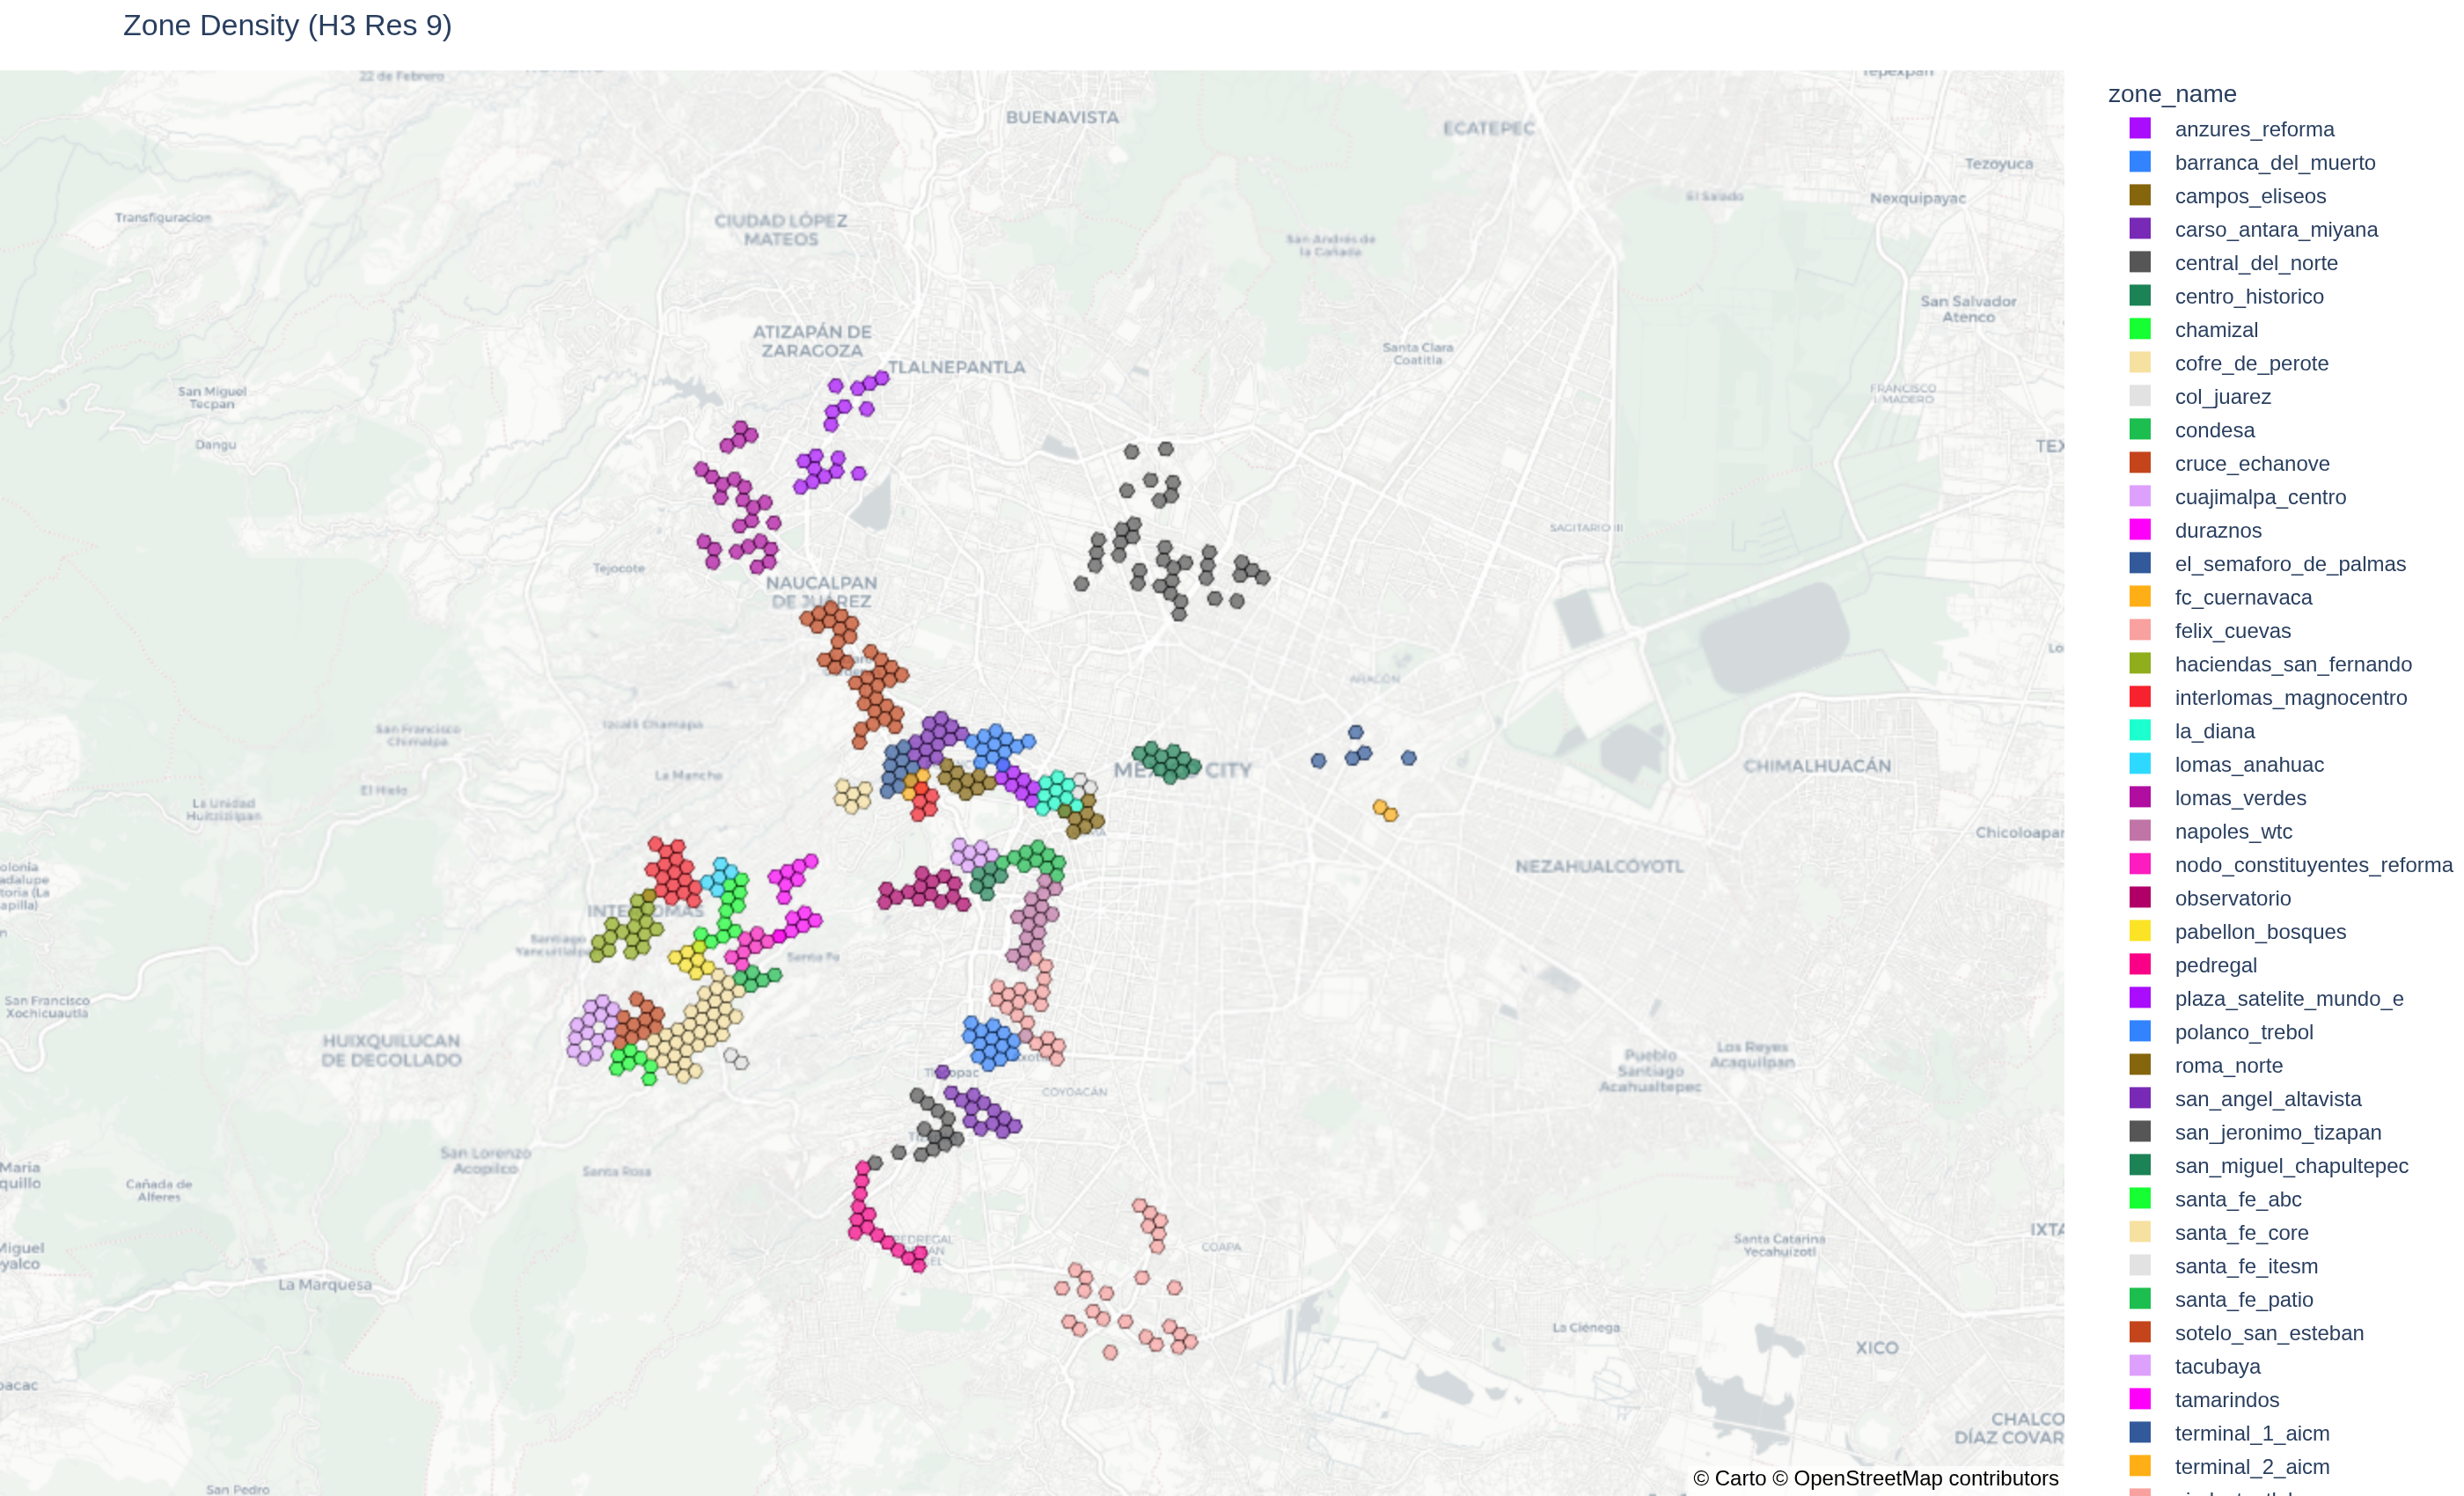

In [32]:
display(Markdown("### H3 Grid (Res 9)"))

try:
    if 'df_h3_final' not in locals():
        raise NameError("DataFrame 'df_h3_final' not in memory. Run 3.1 first.")

    def get_h3_boundary(h3_id):
        try:
            coords = h3.cell_to_boundary(h3_id)  # H3 v4+
        except AttributeError:
            coords = h3.h3_to_geo_boundary(h3_id)  # H3 v3
        # Swap (lat, lon) to (lon, lat) for Shapely/GeoJSON
        return Polygon([(lon, lat) for lat, lon in coords])

    print("Generating vector geometries for visualization...")
    df_h3_viz = df_h3_final.copy()
    df_h3_viz['geometry'] = df_h3_viz['h3_index'].apply(get_h3_boundary)
    gdf_h3 = gpd.GeoDataFrame(df_h3_viz, geometry='geometry', crs="EPSG:4326")

    gdf_h3.sort_values(by='zone_name', inplace=True)

    fig = px.choropleth_mapbox(
        gdf_h3,
        geojson=gdf_h3.geometry.__geo_interface__,
        locations=gdf_h3.index,
        color="zone_name",
        hover_name="zone_name",
        hover_data={"h3_index": True, "offer_count": True},
        mapbox_style="carto-positron",
        center={"lat": 19.4288, "lon": -99.1747},  # Centered on the Anzures/Polanco core
        zoom=10.5,
        height=850,
        opacity=0.7,
        title='Zone Density (H3 Res 9)',
        color_discrete_sequence=px.colors.qualitative.Alphabet
    )

    fig.update_traces(marker_line_width=0.5, marker_line_color='black')
    fig.update_layout(margin=dict(l=0, r=0, t=40, b=0))
    fig.write_image('/tmp/claude-1000/-workspaces-pienza/7bcaaeda-53a2-45bb-a9b4-f7582f9dce1b/scratchpad/0407_h3_grid.png', width=1400, height=850, scale=2)
    from IPython.display import Image, display as _d
    _d(Image(filename='/tmp/claude-1000/-workspaces-pienza/7bcaaeda-53a2-45bb-a9b4-f7582f9dce1b/scratchpad/0407_h3_grid.png'))

except Exception as e:
    print(f"ERROR IN H3 GRID: {e}")


## Phase 4 — Label generation & manual mapping

Generates weighted-centroid labels (positioned at each zone's true demand center, not its geometric center), exports a manual-mapping template for human review, then applies a canonical name-to-Kepler-ID mapping (fixing a second ID mismatch on zones 42/43).

#### 4.1 — Unique labels for 3D clusters (weighted centroid)

In [33]:
display(Markdown("### Label generation: weighted 3D centroids"))

try:
    if 'df_kepler_clean' not in locals():
        raise NameError("DataFrame 'df_kepler_clean' not in memory.")

    # 1. Data prep (clean, no noise/unassigned)
    df_points = df_kepler_clean.copy()

    # 2. Weighted centroid (real density)
    print("Calculating spatial anchors based on offer density...")
    cluster_labels_df = df_points.groupby('zone_name').agg({
        'dropoff_lat': 'mean',
        'dropoff_lon': 'mean',
        'offer_id': 'count'  # Volume metric for the tooltip
    }).reset_index()

    # 3. Topological blueprint (canonical indexing)
    cluster_labels_df = cluster_labels_df.sort_values(by='zone_name').reset_index(drop=True)
    cluster_labels_df['cluster_generic_id'] = cluster_labels_df.index + 1

    # 4. Local export
    OUTPUT_CLUSTER_LABELS = f"{DUMP_DIR}/{PREFIX}_cluster_3d_labels_streamlit.csv"
    cluster_labels_df.to_csv(OUTPUT_CLUSTER_LABELS, index=False)

    display(Markdown(f"3D label file exported successfully to: `{OUTPUT_CLUSTER_LABELS}`"))

    print("\nFirst 5 topological anchors:")
    display(cluster_labels_df[['cluster_generic_id', 'zone_name', 'offer_id']].head())

except Exception as e:
    print(f"ERROR IN 3D LABEL GENERATION: {e}")


### Label generation: weighted 3D centroids

Calculating spatial anchors based on offer density...


3D label file exported successfully to: `/workspaces/pienza/data/dumped_files/0407_cluster_3d_labels_streamlit.csv`


First 5 topological anchors:


,cluster_generic_id,zone_name,offer_id
0,1,anzures_reforma,59
1,2,barranca_del_muerto,32
2,3,campos_eliseos,75
3,4,carso_antara_miyana,169
4,5,central_del_norte,72


#### 4.2 — Manual mapping template

Exports a blank template (weighted centroid per zone, empty `manual_id`/`comentarios` columns) for hand-reviewing the map in Kepler.gl.

In [34]:
try:
    if 'df_h3_final' not in locals():
        raise NameError("DataFrame 'df_h3_final' not in memory. Run the H3 distillation cell first.")

    df_work = df_h3_final.copy()

    # --- 1. Spatial decoding (H3 -> lat/lon) ---
    print("Decoding hexagons to spherical coordinates...")
    def h3_to_coords(h3_id):
        try:
            return h3.cell_to_latlng(h3_id)  # H3 v4+
        except AttributeError:
            return h3.h3_to_geo(h3_id)  # H3 v3

    df_work['coords'] = df_work['h3_index'].apply(h3_to_coords)
    df_work['lat'] = df_work['coords'].apply(lambda x: x[0])
    df_work['lon'] = df_work['coords'].apply(lambda x: x[1])

    # --- 2. Center of mass (weighted by offer volume) ---
    print("Calculating the weighted centroid by offer volume...")
    df_work['w_lat'] = df_work['lat'] * df_work['offer_count']
    df_work['w_lon'] = df_work['lon'] * df_work['offer_count']

    mapping_session = df_work.groupby('zone_name').agg({
        'w_lat': 'sum',
        'w_lon': 'sum',
        'offer_count': 'sum'
    }).reset_index()

    mapping_session['lat_anchor'] = mapping_session['w_lat'] / mapping_session['offer_count']
    mapping_session['lon_anchor'] = mapping_session['w_lon'] / mapping_session['offer_count']

    # --- 3. Prep for human intervention ---
    mapping_session['manual_id'] = ""
    mapping_session['comentarios'] = ""

    # --- 4. Local export ---
    SESSION_PATH = f"{DUMP_DIR}/{PREFIX}_working_session_mapping_streamlit.csv"

    mapping_session[['zone_name', 'manual_id', 'lat_anchor', 'lon_anchor', 'offer_count', 'comentarios']].to_csv(SESSION_PATH, index=False)

    display(Markdown(f"Manual mapping template generated at: `{SESSION_PATH}`"))



    print("\nZones with the highest offer volume (top 10):")
    display(mapping_session[['zone_name', 'offer_count', 'lat_anchor', 'lon_anchor']].sort_values('offer_count', ascending=False).head(10))

except Exception as e:
    print(f"ERROR IN SENSORY MAPPING: {e}")


Decoding hexagons to spherical coordinates...
Calculating the weighted centroid by offer volume...


Manual mapping template generated at: `/workspaces/pienza/data/dumped_files/0407_working_session_mapping_streamlit.csv`


Zones with the highest offer volume (top 10):


,zone_name,offer_count,lat_anchor,lon_anchor
33,santa_fe_core,331,19.364837,-99.266792
3,carso_antara_miyana,169,19.440383,-99.201628
40,terminal_2_aicm,111,19.422027,-99.077881
39,terminal_1_aicm,111,19.435519,-99.072303
36,sotelo_san_esteban,104,19.454509,-99.221036
13,el_semaforo_de_palmas,96,19.433031,-99.211443
17,interlomas_magnocentro,86,19.404158,-99.273735
22,nodo_constituyentes_reforma,84,19.387183,-99.251596
2,campos_eliseos,75,19.429177,-99.194007
27,polanco_trebol,74,19.438013,-99.183556


#### 4.3 — Canonical naming + Kepler dummy ID

Restores canonical zone names from the cluster IDs and maps them to sequential Kepler IDs (1-44), renders a validation map, and exports.

In [35]:
display(Markdown("### Canonical names + Kepler dummy IDs"))

try:
    if 'df_hdbscan_analysis' not in locals():
        raise NameError("DataFrame 'df_hdbscan_analysis' not in memory.")

    OUTPUT_KEPLER = f"{DUMP_DIR}/{PREFIX}_hdbscan_kepler_final_streamlit.csv"

    # --- 1. Processing (uses the single-source ZONE_NAMES/KEPLER_ID_MAP from 2.2) ---
    print("Applying identity transformations...")
    df_viz = df_hdbscan_analysis.copy()

    # A. Restore canonical zone name
    df_viz['hdbscan_cluster_id'] = df_viz['hdbscan_cluster_id'].astype(int)
    df_viz['zone_name'] = df_viz['hdbscan_cluster_id'].map(ZONE_NAMES)

    # B. Create Kepler dummy ID from the name
    df_viz['kepler_id'] = df_viz['zone_name'].map(KEPLER_ID_MAP)

    # C. Full cleanup: drop -1 (unassigned)
    df_viz = df_viz[df_viz['hdbscan_cluster_id'] != -1]
    df_viz = df_viz.dropna(subset=['kepler_id'])

    # --- 2. Validation map (dummy ID visual) ---
    print("Generating validation map...")
    fig = px.scatter_mapbox(
        df_viz,
        lat="lat_viz",
        lon="lon_viz",
        color="zone_name",
        hover_name="zone_name",
        hover_data={"hdbscan_cluster_id": True, "kepler_id": True},
        mapbox_style="carto-positron",
        zoom=10.5,
        height=800,
        title='Validation: Canonical Names & Kepler IDs',
        color_discrete_sequence=px.colors.qualitative.Alphabet
    )

    fig.update_traces(marker=dict(size=6, opacity=0.7))
    fig.update_layout(margin=dict(l=0, r=0, t=40, b=0))
    fig.show()

    # --- 3. Local export ---
    df_viz.to_csv(OUTPUT_KEPLER, index=False)
    display(Markdown(f"File ready for Kepler (with kepler_id): `{OUTPUT_KEPLER}`"))

except Exception as e:
    print(f"ERROR IN CANONICAL NAMING: {e}")

### Canonical names + Kepler dummy IDs

Applying identity transformations...
Generating validation map...


File ready for Kepler (with kepler_id): `/workspaces/pienza/data/dumped_files/0407_hdbscan_kepler_final_streamlit.csv`

#### 4.4 — Unique label generator (weighted centroid, final fix)

Repairs any missing `kepler_id` via a name-to-ID map, decodes H3 hexagons back to coordinates, and computes the final weighted-centroid label per zone.

In [36]:
display(Markdown("### Label generator: weighted centroids (final)"))

# 1. Kepler ID lookup (uses the single-source KEPLER_ID_MAP from 2.2, not a local copy)

try:
    # 2. Identify data source
    source_df = None
    if 'df_h3_final' in locals():
        source_df = df_h3_final
    elif 'df_h3_sandbox' in locals():
        source_df = df_h3_sandbox

    if source_df is None:
        raise NameError("No hexagon table detected (df_h3_final). Run the H3 distillation cell first.")

    df_labels = source_df.copy()

    # 3. Re-inject missing columns (kepler_id and coordinates)
    if 'kepler_id' not in df_labels.columns:
        df_labels['kepler_id'] = df_labels['zone_name'].map(KEPLER_ID_MAP)

    def h3_to_coords(h3_id):
        try:
            return h3.cell_to_latlng(h3_id)  # H3 v4+
        except AttributeError:
            return h3.h3_to_geo(h3_id)  # H3 v3

    print("Decoding hexagons and calculating weights...")
    df_labels['coords'] = df_labels['h3_index'].apply(h3_to_coords)
    df_labels['lat'] = df_labels['coords'].apply(lambda x: x[0])
    df_labels['lon'] = df_labels['coords'].apply(lambda x: x[1])

    # 4. Weighted centroid (demand center)
    df_labels['w_lat'] = df_labels['lat'] * df_labels['offer_count']
    df_labels['w_lon'] = df_labels['lon'] * df_labels['offer_count']

    labels_final = df_labels.groupby(['kepler_id', 'zone_name']).agg({
        'w_lat': 'sum',
        'w_lon': 'sum',
        'offer_count': 'sum'
    }).reset_index()

    labels_final['lat_center'] = labels_final['w_lat'] / labels_final['offer_count']
    labels_final['lon_center'] = labels_final['w_lon'] / labels_final['offer_count']

    # 5. Export
    LABEL_PATH = f"{DUMP_DIR}/{PREFIX}_solo_etiquetas_opus_streamlit.csv"
    labels_final[['kepler_id', 'zone_name', 'lat_center', 'lon_center']].to_csv(LABEL_PATH, index=False)

    display(Markdown("### Unique labels generated"))
    print(f"File with {len(labels_final)} labels saved to: {LABEL_PATH}")

    display(labels_final[['kepler_id', 'zone_name', 'offer_count']].sort_values('kepler_id').head())

except Exception as e:
    print(f"ERROR IN LABEL GENERATION: {e}")


### Label generator: weighted centroids (final)

Decoding hexagons and calculating weights...


### Unique labels generated

File with 44 labels saved to: /workspaces/pienza/data/dumped_files/0407_solo_etiquetas_opus_streamlit.csv


,kepler_id,zone_name,offer_count
0,1,lomas_verdes,45
1,2,plaza_satelite_mundo_e,31
2,3,central_del_norte,72
3,4,terminal_1_aicm,111
4,5,terminal_2_aicm,111


## Phase 5 — Validation & Golden Master

Visually audits the zones flagged as suspicious (42/43) via an interactive Folium map, then forges the final "Golden Master" table joining operational (fare/EPH) and spatial (H3, HDBSCAN name) data.

#### 5.1 — Identity audit with Folium (fix 42/43, 36/37)

Plots every zone's weighted-centroid label on a Folium map, highlighting zones 42/43 and 36/37 in red for a manual visual sanity check.

In [37]:
# 1. Define the map center (south CDMX)
map_center = [labels_final['lat_center'].mean(), labels_final['lon_center'].mean()]
m = folium.Map(location=map_center, zoom_start=12, tiles='OpenStreetMap')

# 2. Add markers with visible labels
for idx, row in labels_final.iterrows():
    # Special color for the suspects (42 and 43)
    dot_color = 'red' if row['kepler_id'] in [42, 43, 36, 37] else 'blue'

    folium.CircleMarker(
        location=[row['lat_center'], row['lon_center']],
        radius=6,
        color=dot_color,
        fill=True,
        fill_color=dot_color,
        tooltip=f"ID: {row['kepler_id']} - {row['zone_name']}"
    ).add_to(m)

    # Add the floating ID number (DivIcon)
    folium.map.Marker(
        [row['lat_center'], row['lon_center']],
        icon=folium.DivIcon(
            icon_size=(150, 36),
            icon_anchor=(7, 20),
            html=f'<div style="font-size: 14pt; color: {dot_color}; font-weight: bold;">{row["kepler_id"]}</div>',
        )
    ).add_to(m)

# 3. Show the map
display(Markdown("### Audit map: zones 42 and 43 highlighted for review"))
m


### Audit map: zones 42 and 43 highlighted for review

#### 5.2 — Golden Master table (SQLite)

Joins operational fields (fare, product, rejection reason, EPH) from `pienza.db` with the spatial assignment (H3 hex, HDBSCAN zone name) built above, adds per-hexagon offer volume, and exports the final table.

In [38]:
display(Markdown("### Building the Golden Master table (SQLite)"))

# 1. SQL query (adjusted for SQLite, no BigQuery prefixes)
query = """
SELECT
    o.offer_id,
    pc.category_name AS product_category,
    ROUND(o.upfront_fare, 2) AS upfront_fare,
    COALESCE(rp.reason_primary_description, 'NULL (Accepted)') AS rejection_reason,
    ROUND(ef.eph_operational, 2) AS eph_operational
FROM offers o
LEFT JOIN engineered_features ef ON o.offer_id = ef.offer_id_fk
LEFT JOIN product_category pc ON o.product_category_fk = pc.product_category_id
LEFT JOIN reason_primary rp ON o.reason_primary_fk = rp.reason_primary_id
"""

print("Extracting financial data from pienza.db...")
df_sql = pd.read_sql(query, db_engine)

# 2. Prepare spatial data (using the existing df_viz)
df_spatial = df_viz.copy()

# Compute H3 res 9
def get_h3_fast(row):
    try:
        return h3.latlng_to_cell(row['dropoff_lat'], row['dropoff_lon'], 9)
    except Exception:
        return h3.geo_to_h3(row['dropoff_lat'], row['dropoff_lon'], 9)

df_spatial['dropoff_h3_hex_id'] = df_spatial.apply(get_h3_fast, axis=1)

# Rename to the ERD schema
df_spatial = df_spatial.rename(columns={
    'hdbscan_cluster_id': 'dropoff_hdbscan_id',
    'zone_name': 'dropoff_hdbscan_name'
})

df_spatial = df_spatial[['offer_id', 'dropoff_h3_hex_id', 'dropoff_hdbscan_id', 'dropoff_hdbscan_name']]

# 3. Final join (operational + spatial)
print("Running the spatial join...")
gold_master_df = pd.merge(df_sql, df_spatial, on='offer_id', how='inner')

# 4. Volume injection and Kepler render trick
print("Calculating density and applying the opacity render trick...")

# A) Total volume per hexagon
counts = gold_master_df.groupby('dropoff_h3_hex_id').size().reset_index(name='offer_volume')
gold_master_df = gold_master_df.merge(counts, on='dropoff_h3_hex_id')

# B) The Kepler trick: a column to optimize hexagon rendering
gold_master_df['render_h3_hex'] = gold_master_df['dropoff_h3_hex_id'].mask(
    gold_master_df.duplicated(subset=['dropoff_h3_hex_id'])
)

# 5. Export
OUTPUT_GOLD = f"{DUMP_DIR}/{PREFIX}_gold_master_dropoffs_lean.csv"
gold_master_df.to_csv(OUTPUT_GOLD, index=False)

display(Markdown(f"Golden Master table ready: `{OUTPUT_GOLD}`"))
print(f"Final dimensions: {gold_master_df.shape}")
display(gold_master_df.head(5))


### Building the Golden Master table (SQLite)

Extracting financial data from pienza.db...
Running the spatial join...
Calculating density and applying the opacity render trick...


Golden Master table ready: `/workspaces/pienza/data/dumped_files/0407_gold_master_dropoffs_lean.csv`

Final dimensions: (2614, 10)


,offer_id,product_category,upfront_fare,rejection_reason,eph_operational,dropoff_h3_hex_id,dropoff_hdbscan_id,dropoff_hdbscan_name,offer_volume,render_h3_hex
0,OF02210,uberx,97.82,dropoff_non_operational,167.69,894995b9453ffff,0,terminal_1_aicm,99,894995b9453ffff
1,OF00411,comfort,168.08,dropoff_non_operational,245.97,894995b9453ffff,0,terminal_1_aicm,99,NaN
2,OF01157,comfort,140.29,dropoff_non_operational,311.76,894995b9453ffff,0,terminal_1_aicm,99,NaN
3,OF01850,envíos_uber,126.34,dropoff_non_operational,151.61,894995b9453ffff,0,terminal_1_aicm,99,NaN
4,OF03729,uberx,98.14,dropoff_non_operational,267.65,894995b9453ffff,0,terminal_1_aicm,99,NaN


---

## Appendix — variable journey


<div align="center">
<picture>
  <source media="(prefers-color-scheme: dark)" srcset="../assets/0407_diagram2-dark.png">
  <source media="(prefers-color-scheme: light)" srcset="../assets/0407_diagram2-light.png">
  <img alt="0407_diagram2 flowchart" src="../assets/0407_diagram2-light.png" width="760">
</picture>
</div>
